In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
!pip install xarray netcdf4 matplotlib cartopy numpy pandas dask xclim
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [24]:
#loading main dataset
url = "https://data.giss.nasa.gov/pub/gistemp/gistemp1200_GHCNv4_ERSSTv5.nc.gz"
gz_path = "/content/drive/MyDrive/gistemp1200_GHCNv4_ERSSTv5.nc.gz"
nc_path = "/content/drive/MyDrive/gistemp1200_GHCNv4_ERSSTv5.nc"

# ~23 MB — download once into Drive, then unzip
if not os.path.exists(nc_path):
    !wget -O "{gz_path}" "{url}"
    !gunzip -f "{gz_path}"

In [25]:
ds = xr.open_dataset(nc_path)
print (ds)
ds.tempanomaly

<xarray.Dataset> Size: 114MB
Dimensions:      (time: 1757, nv: 2, lat: 90, lon: 180)
Coordinates:
  * time         (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2026-05-15
  * lat          (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * lon          (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
Dimensions without coordinates: nv
Data variables:
    time_bnds    (time, nv) datetime64[ns] 28kB ...
    tempanomaly  (time, lat, lon) float32 114MB ...
Attributes:
    title:        GISTEMP Surface Temperature Analysis
    institution:  NASA Goddard Institute for Space Studies
    source:       http://data.giss.nasa.gov/gistemp/
    Conventions:  CF-1.6
    history:      Created 2026-06-09 04:38:32 by SBBX_to_nc 2.0 - ILAND=1200,...


<xarray.DataArray 'tempanomaly' (time: 1757, lat: 90, lon: 180)> Size: 114MB
[28463400 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2026-05-15
  * lat      (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
Attributes:
    long_name:     Surface temperature anomaly
    units:         K
    cell_methods:  time: mean

In [26]:
#filtering out india from the global dataset
india = ds.tempanomaly.sel(lat=slice(6, 35), lon=slice(68, 98))

#resampling time from monthly to yearly
india_annual = india.resample(time="YS").mean()


In [27]:

#compute cos(lat) weights, for area-weighted spatial mean
weights = np.cos(np.deg2rad(india_annual.lat))

#apply weights and then average over lat and lon
india_ts=india_annual.weighted(weights).mean(["lat","lon"])

# india_ts is now shape (time,) — one value per year


In [28]:
#updating baseline to 1981–2010
baseline_mean = india_ts.sel(time=slice("1981", "2010")).mean()
india_ts_rebased = india_ts - baseline_mean

print(india_ts_rebased.sel(time=slice("1981", "2010")).mean().values)


-7.82310962677002e-09


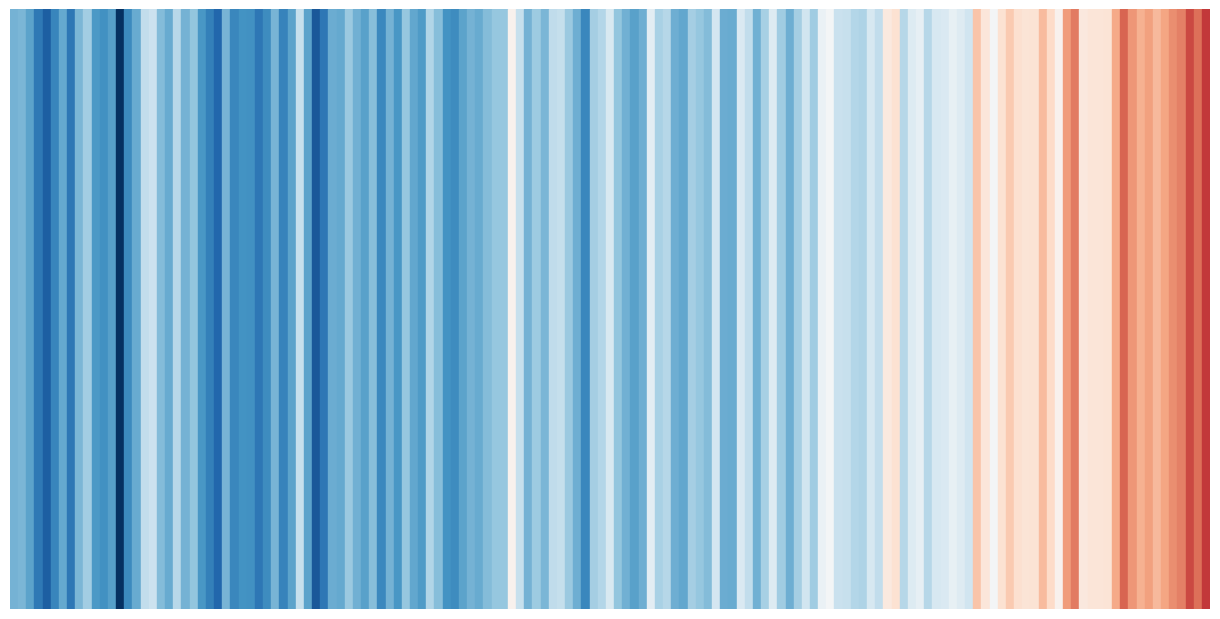

In [35]:
#years and values as numpy arrays
years = india_ts_rebased.time.dt.year.values
values = india_ts_rebased.values

#set up a colourmap centered on 0
vmax = np.nanmax(np.abs(values))
norm=mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax = vmax)
cmap = plt.get_cmap("RdBu_r")

#one vertical bar per year
fig,ax = plt.subplots(figsize = (12,6))
for i, (year,val) in enumerate(zip(years,values)):
  ax.axvspan(i, i+1, color=cmap(norm(val)))

ax.set_xlim(0, len(years))
ax.axis("off")

plt.tight_layout(pad=0)
# Save the plot to Google Drive
plt.savefig("/content/drive/MyDrive/india_warming_stripes.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
#Now creating a warming map of India, starting with a per-grid trend

#fit a linear trend at every cell, to track how many °C the temperature changes per unit time.
fit = india_annual.polyfit(dim="time",deg=1)
slope = fit.sel(degree=1).polyfit_coefficients

#since the slope is currently in °C/nanosecond we now convert it to °C/decade
ns_per_decade = 10 * 365.25 * 24 * 3600 * 1e9

slope_decade=slope * ns_per_decade
print (slope_decade)


<xarray.DataArray 'polyfit_coefficients' (lat: 15, lon: 15)> Size: 2kB
array([[0.09580252, 0.0945641 , 0.07802475, 0.08818353, 0.07871135,
        0.06855286, 0.06827184, 0.07470811, 0.07870321, 0.07666312,
        0.07428134, 0.07196755, 0.07030051, 0.0784581 , 0.08334158],
       [0.09392247, 0.09268804, 0.06585123, 0.08556944, 0.07139304,
        0.06557893, 0.0686017 , 0.07473   , 0.07912114, 0.07694487,
        0.07460336, 0.07228342, 0.07074592, 0.06925557, 0.08885508],
       [0.09314097, 0.09171369, 0.07168776, 0.08180552, 0.07092636,
        0.0666919 , 0.07445865, 0.08125629, 0.07887178, 0.07652382,
        0.07422091, 0.07177609, 0.07014746, 0.06908255, 0.09060901],
       [0.09322875, 0.09155422, 0.08865696, 0.07111678, 0.0686432 ,
        0.06851443, 0.07514762, 0.08081124, 0.07822614, 0.07566577,
        0.0732273 , 0.07031076, 0.06846385, 0.06770232, 0.0931882 ],
       [0.09310236, 0.09153083, 0.07361238, 0.07258665, 0.07189952,
        0.07156393, 0.07641602, 0.0802114

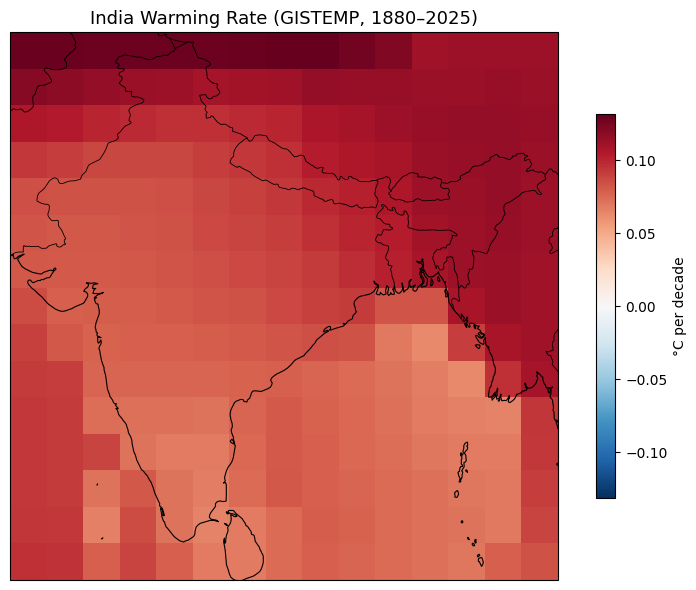

In [33]:
#plotting the slope data into a warming map

fig, ax = plt.subplots(figsize=(8,6), subplot_kw={"projection": ccrs.PlateCarree()}
)

vmax=float(abs(slope_decade).max())

#plotting data on the map
im = ax.pcolormesh(
    slope_decade.lon,
    slope_decade.lat,
    slope_decade,
    cmap="RdBu_r",
    vmin=-vmax, vmax=vmax,
    transform=ccrs.PlateCarree()
)

#adding geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)

#cropping to india
ax.set_extent([68,98,6,36], crs=ccrs.PlateCarree())

plt.colorbar(im, ax=ax, label ="°C per decade", shrink=0.7)

ax.set_title("India Warming Rate (GISTEMP, 1880–2025)", fontsize=13)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/india_warming_map.png", dpi=150)
plt.show()

